#  Mini-Projet : Analyse de Données pour la Stratégie Marketing
### US Superstore Dataset

Ce notebook répond, étape par étape, aux questions du mini-projet :
analyse géographique, clients, catégories produits, Pareto et séries chronologiques.


## Étape 1 – Imports et Chargement du Dataset

In [1]:
# On importe toutes les bibliothèques dont on aura besoin
import pandas as pd          # pour manipuler les données (tableaux)
import numpy as np            # pour les calculs numériques
import matplotlib.pyplot as plt  # pour les graphiques
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

print('✅ Bibliothèques importées avec succès !')


ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
# Chargement du fichier
# (si le fichier est .xls, utiliser engine='xlrd')
df = pd.read_csv('US_Superstore_data.csv')  # ou pd.read_excel('US Superstore data.xls')

# Conversion des colonnes dates
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=False)
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=False)

print(f'Nombre de lignes  : {len(df)}')
print(f'Nombre de colonnes: {df.shape[1]}')
df.head(3)


## Étape 2 – Exploration et Prétraitement

In [ ]:
# Vérification des types de données
print(df.dtypes)


In [ ]:
# Vérification des valeurs manquantes
print('Valeurs manquantes par colonne :')
print(df.isnull().sum())


In [ ]:
# Statistiques descriptives des colonnes numériques
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe().round(2)


---
## Question 1 – Quels États enregistrent le plus de ventes ?

On regroupe les données par État et on additionne les ventes.


In [ ]:
# Grouper par État et sommer les ventes
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False)

print('Top 10 États par Ventes :')
print(state_sales.head(10).apply(lambda x: f'${x:,.0f}').to_frame('Ventes Totales'))


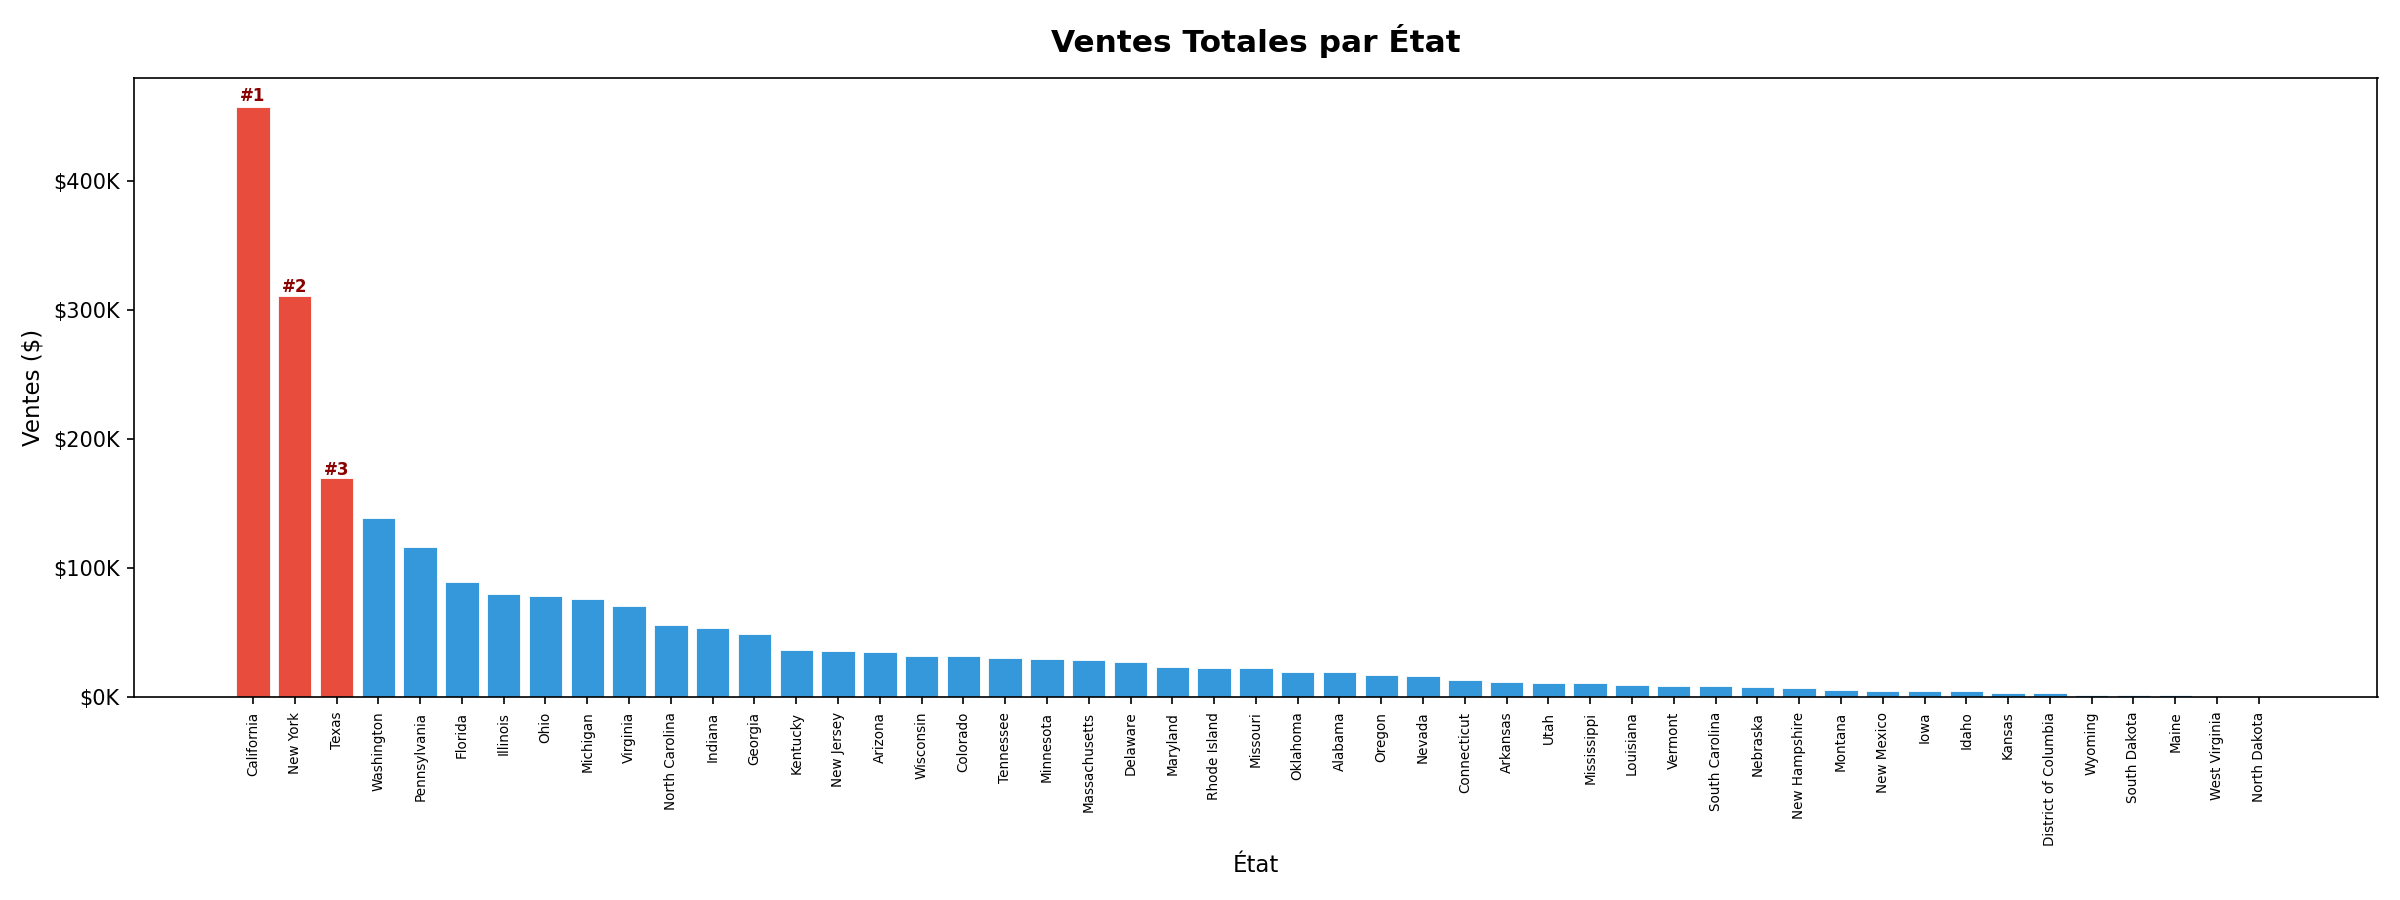

In [ ]:
# Graphique : Ventes par État

**Observation :** La Californie est très largement en tête, suivie de New York et du Texas.
Ces 3 États représentent une part significative du chiffre d'affaires total.


---
## Question 2 – New York vs Californie : CA et Bénéfices

On filtre les données pour ne garder que ces deux États.


In [ ]:
# Filtrer les deux États
ny_ca = df[df['State'].isin(['New York', 'California'])]

# Agréger ventes et bénéfices
comparaison = ny_ca.groupby('State')[['Sales', 'Profit']].sum().round(2)
comparaison['Marge (%)'] = (comparaison['Profit'] / comparaison['Sales'] * 100).round(2)
print(comparaison)


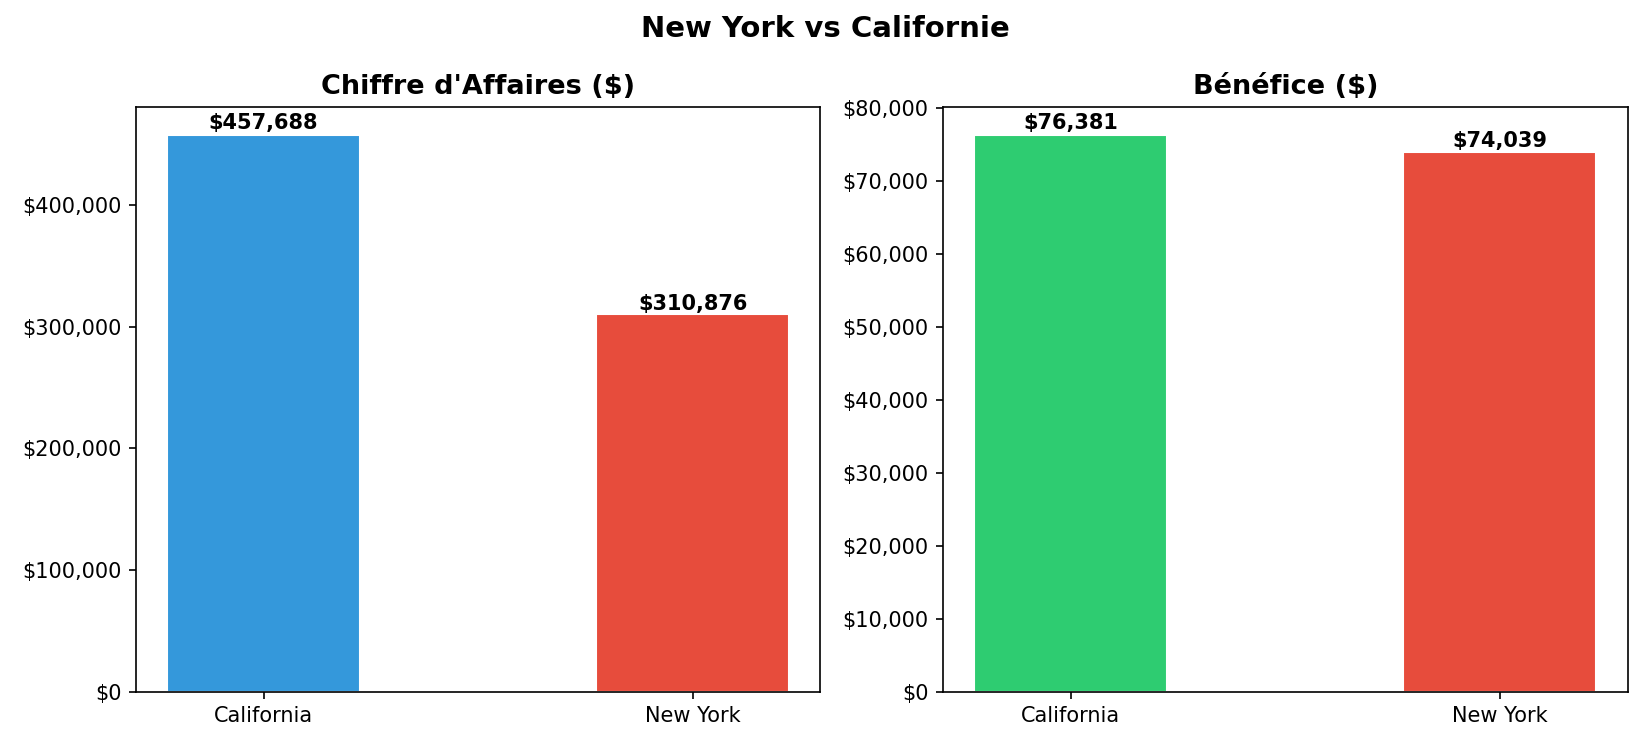

In [ ]:
# Graphique : NY vs Californie

**Observation :**
- La Californie réalise un CA nettement supérieur (~$458K vs ~$311K)
- Les bénéfices sont proches : Californie ~$76K, New York ~$74K
- La marge de New York est donc légèrement supérieure à celle de la Californie


---
## Question 3 – Qui est le client exceptionnel à New York ?

On filtre les commandes de New York et on classe les clients par ventes.


In [ ]:
# Clients de New York uniquement
ny_cust = (df[df['State'] == 'New York']
           .groupby('Customer Name')[['Sales', 'Profit']]
           .sum()
           .sort_values('Sales', ascending=False))

ny_cust['Marge (%)'] = (ny_cust['Profit'] / ny_cust['Sales'] * 100).round(2)
print('Top 5 clients à New York :')
print(ny_cust.head(5).round(2))


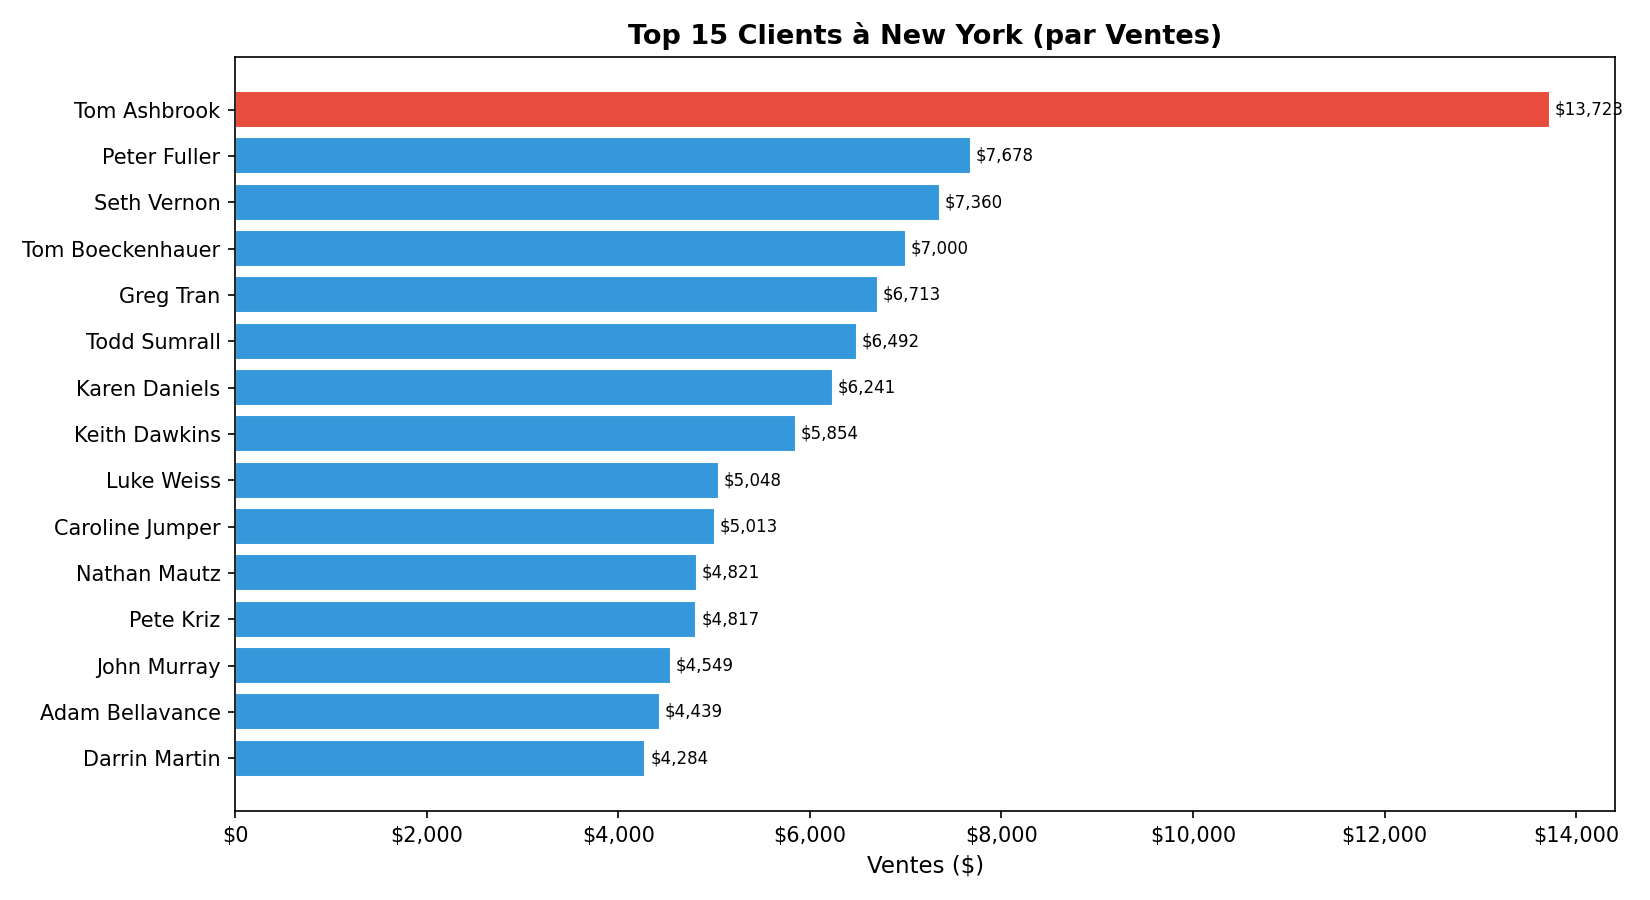

In [ ]:
# Graphique : Clients New York

**Observation :** **Tom Ashbrook** est le client exceptionnel à New York,
avec le chiffre d'affaires le plus élevé de l'État.


---
## Question 4 – Différences de rentabilité entre les États

On calcule la marge bénéficiaire (Profit / Sales × 100) pour chaque État.


In [ ]:
# Calcul de la marge par État
state_agg = df.groupby('State')[['Sales','Profit']].sum()
state_agg['Marge (%)'] = (state_agg['Profit'] / state_agg['Sales'] * 100).round(2)
state_agg = state_agg.sort_values('Marge (%)', ascending=False)

print('États les plus rentables (top 5) :')
print(state_agg.head(5)[['Marge (%)']].to_string())
print('\nÉtats les moins rentables (bottom 5) :')
print(state_agg.tail(5)[['Marge (%)']].to_string())


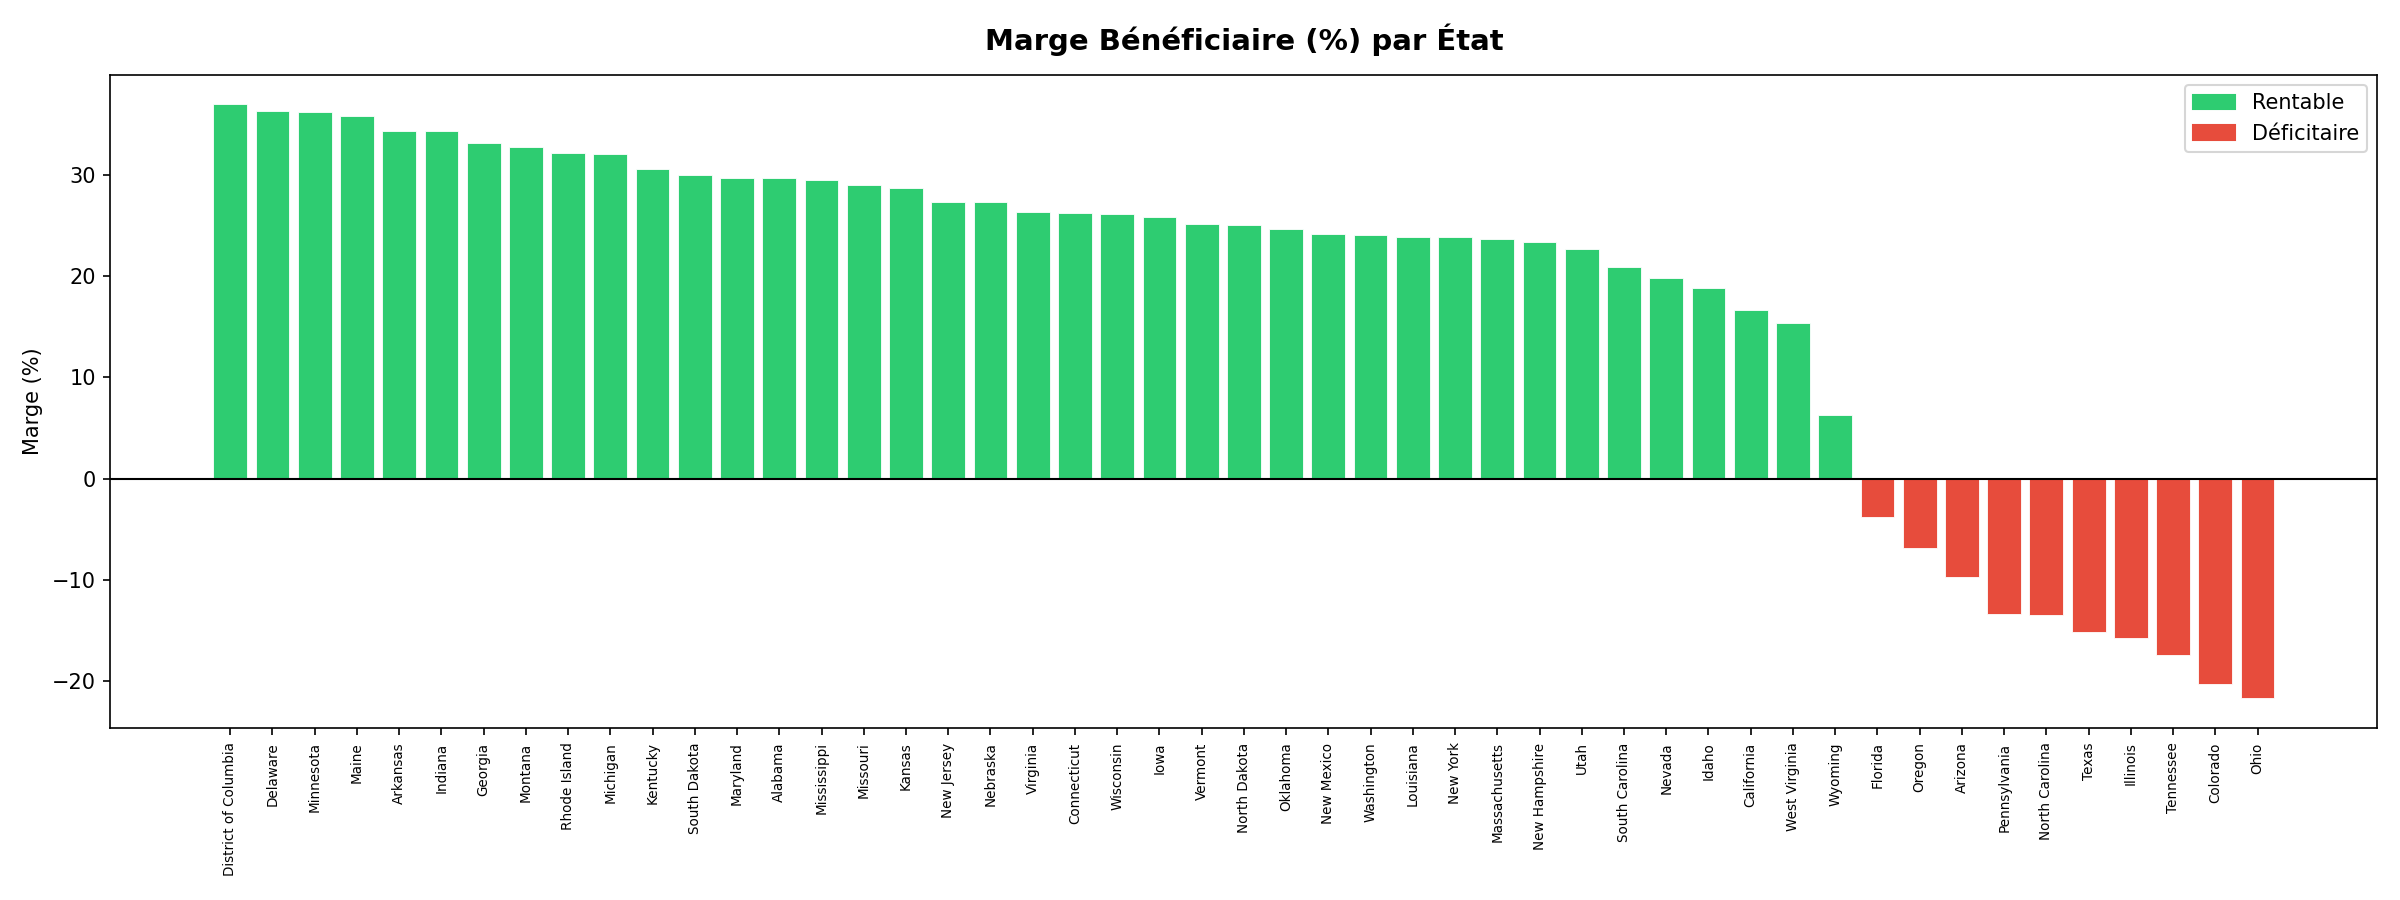

In [ ]:
# Graphique : Marge par État

**Observation :** De grandes disparités existent. Certains États comme **Ohio, Colorado,
Tennessee** affichent des marges fortement négatives (déficitaires), tandis que d'autres
comme **Vermont** ou **Rhode Island** sont très rentables.


---
## Question 5 – Principe de Pareto : Clients et Bénéfices

On cherche à savoir si **20% des clients génèrent 80% des bénéfices**.


In [ ]:
# Bénéfice par client, trié de façon décroissante
cust_profit = df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False)

# On garde uniquement les clients profitable (profit > 0)
cust_profit_pos = cust_profit[cust_profit > 0]

# Calcul du % cumulé
cumul_pct = cust_profit_pos.cumsum() / cust_profit_pos.sum() * 100
x_pct     = np.arange(1, len(cumul_pct)+1) / len(cumul_pct) * 100

# À quel % de clients atteint-on 80% des bénéfices ?
idx80   = np.searchsorted(cumul_pct.values, 80)
x_at_80 = x_pct[idx80]
print(f'→ {x_at_80:.1f}% des clients (profitables) génèrent 80% des bénéfices')
print(f'  Règle de Pareto (20/80) : {"CONFIRMÉ ✅" if x_at_80 <= 25 else "NON STRICTE – concentration plus étalée"}')


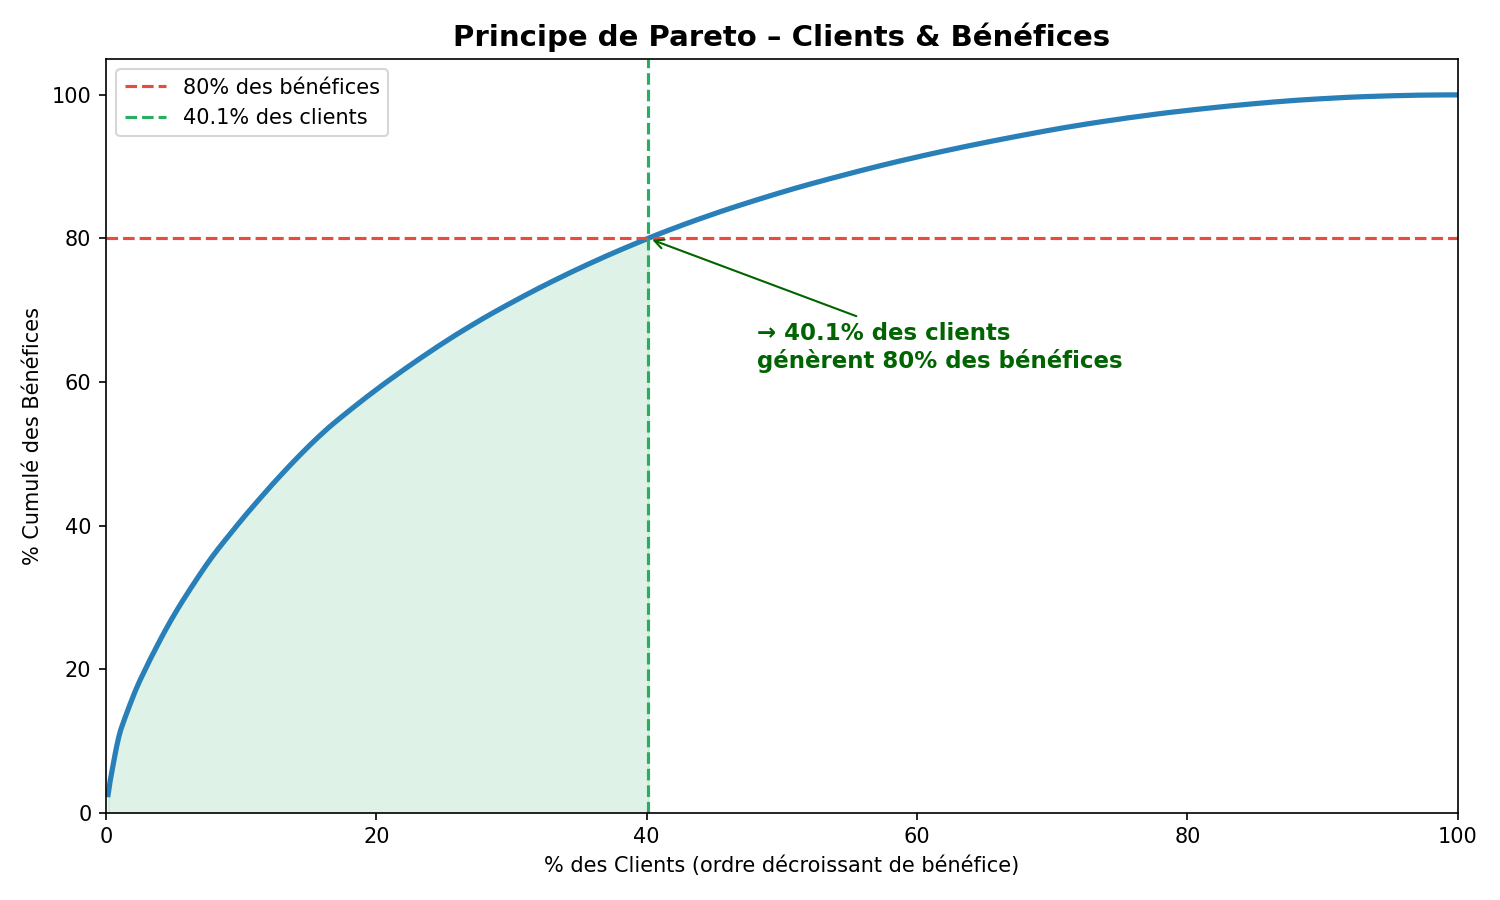

In [ ]:
# Graphique : Pareto Clients / Bénéfices

**Observation :** Environ **40% des clients** génèrent 80% des bénéfices.
La règle stricte 20/80 ne s'applique pas ici, mais la concentration existe bien :
une minorité de clients représente l'essentiel de la valeur créée.

>  **Stratégie :** Identifier et fidéliser ces clients prioritaires.


---
## Question 6 – Top 20 Villes : CA & Bénéfice

On identifie les 20 meilleures villes selon le CA et selon le bénéfice.


In [ ]:
# Agrégation par ville
city_agg = df.groupby('City')[['Sales','Profit']].sum()
city_agg['Marge (%)'] = (city_agg['Profit']/city_agg['Sales']*100).round(2)

top20_sales  = city_agg.sort_values('Sales', ascending=False).head(20)
top20_profit = city_agg.sort_values('Profit', ascending=False).head(20)

# Villes présentes dans les deux classements
common = set(top20_sales.index) & set(top20_profit.index)
print(f'Villes dans les 2 top 20 ({len(common)}) : {sorted(common)}')
print('\nTop 5 villes par CA :')
print(top20_sales.head(5)[['Sales','Profit','Marge (%)']].round(0).to_string())


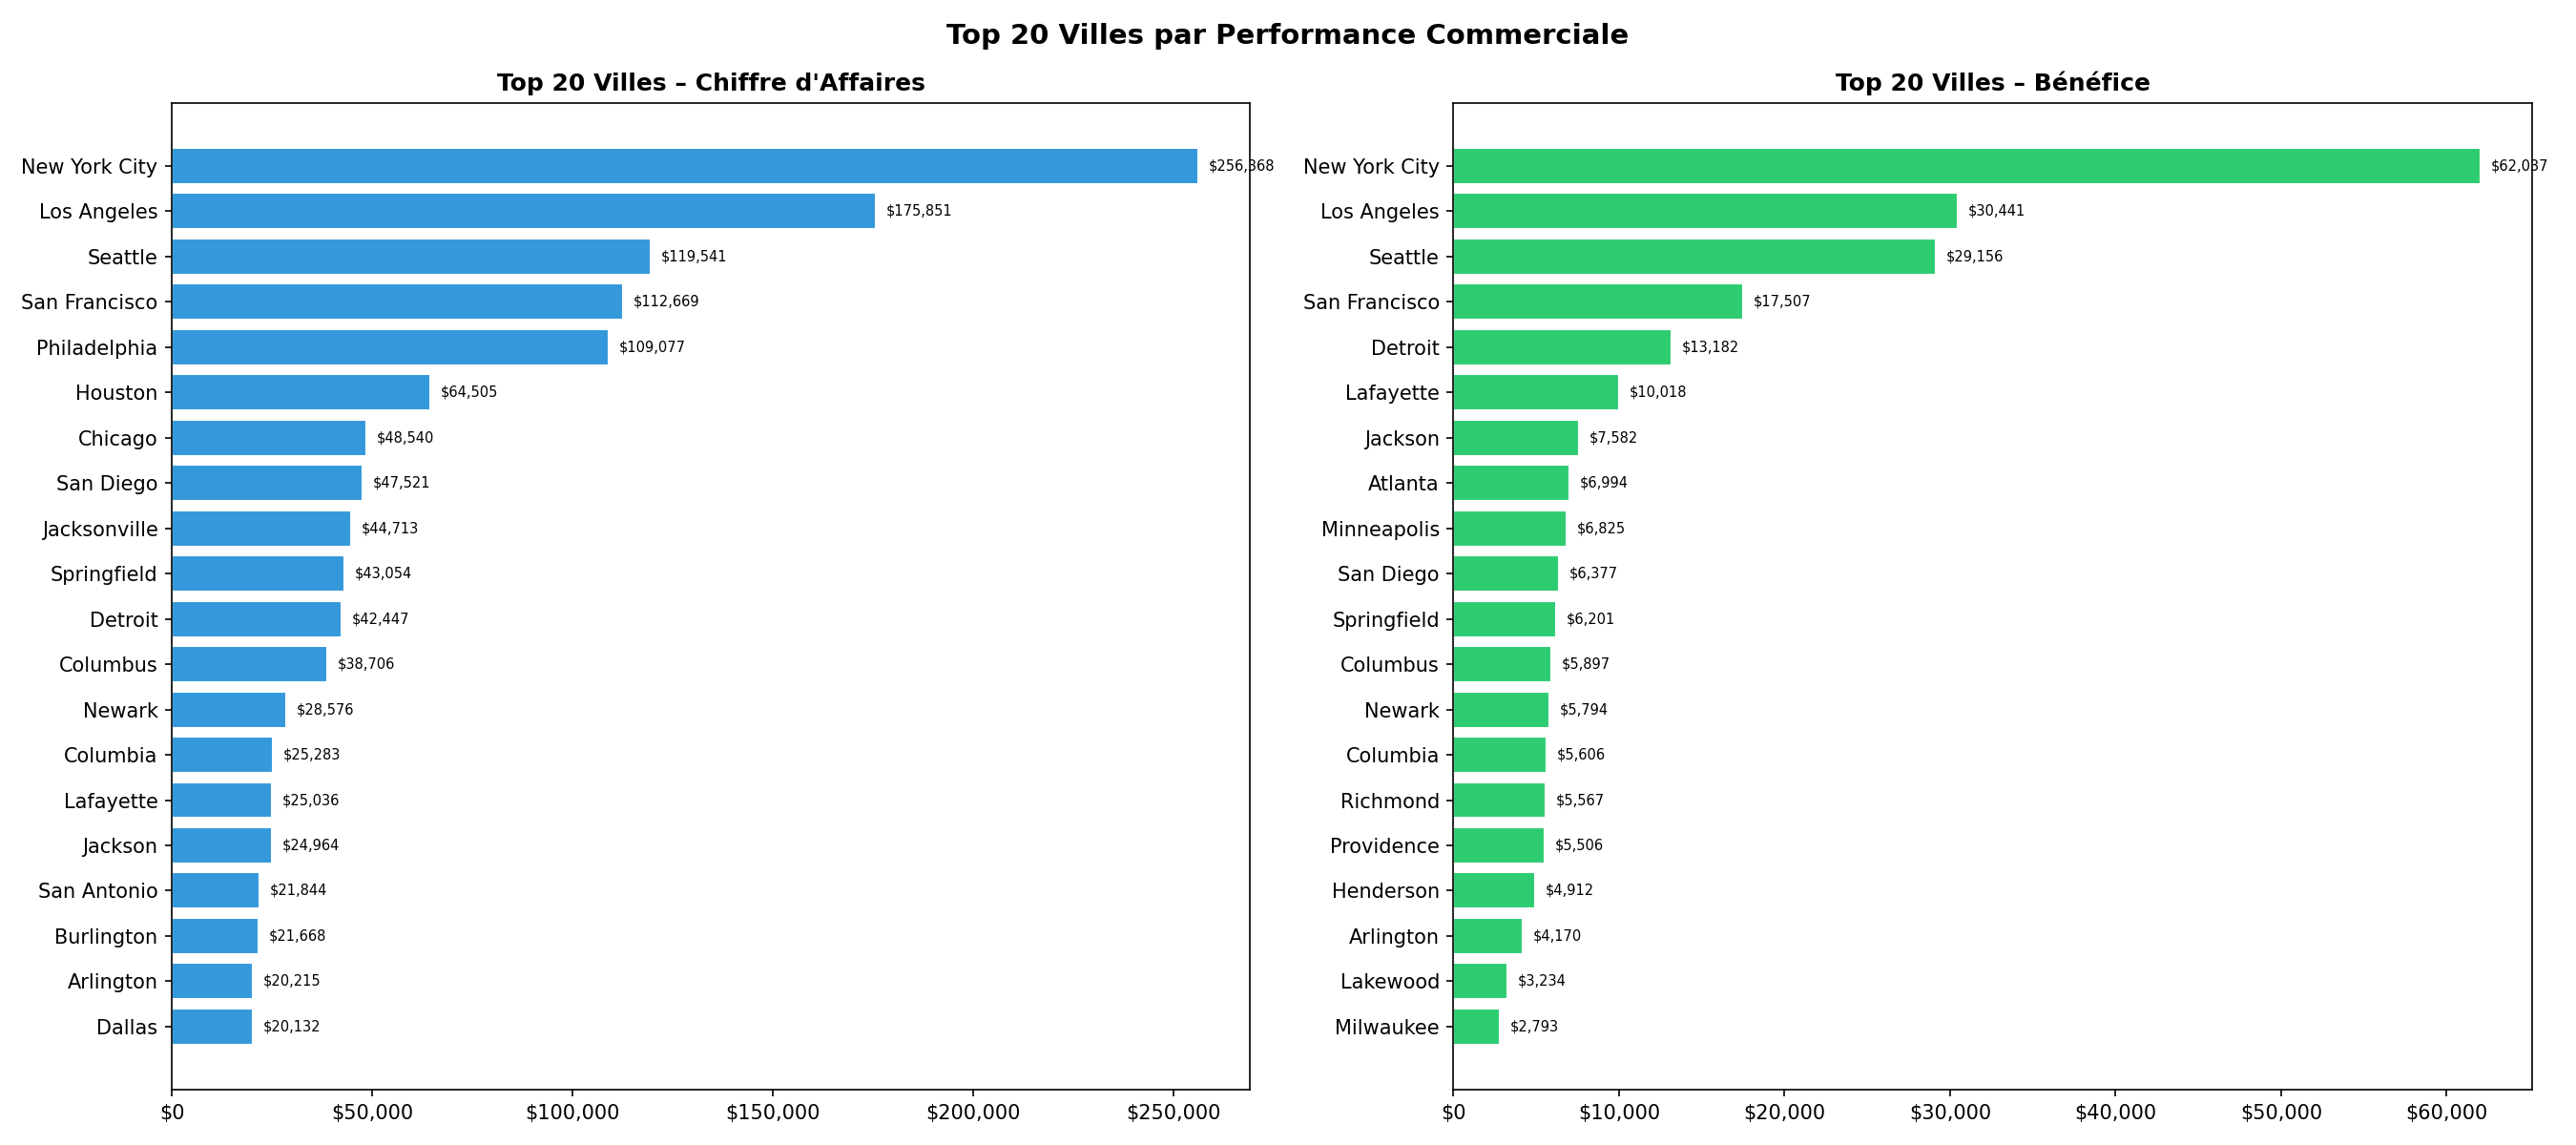

In [ ]:
# Graphique : Top 20 Villes

**Observation :**
- **New York City** et **Los Angeles** dominent largement en CA.
- Certaines villes à fort CA ont une **marge négative** (ex : Philadelphie) → à surveiller.
- Les villes à la fois dans le top CA et top bénéfice sont les cibles prioritaires.


---
## Question 7 – Top 20 Clients par Ventes


In [ ]:
# Top 20 clients par chiffre d'affaires
top20_cust = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(20)
print(top20_cust.apply(lambda x: f'${x:,.2f}').to_frame('Ventes'))


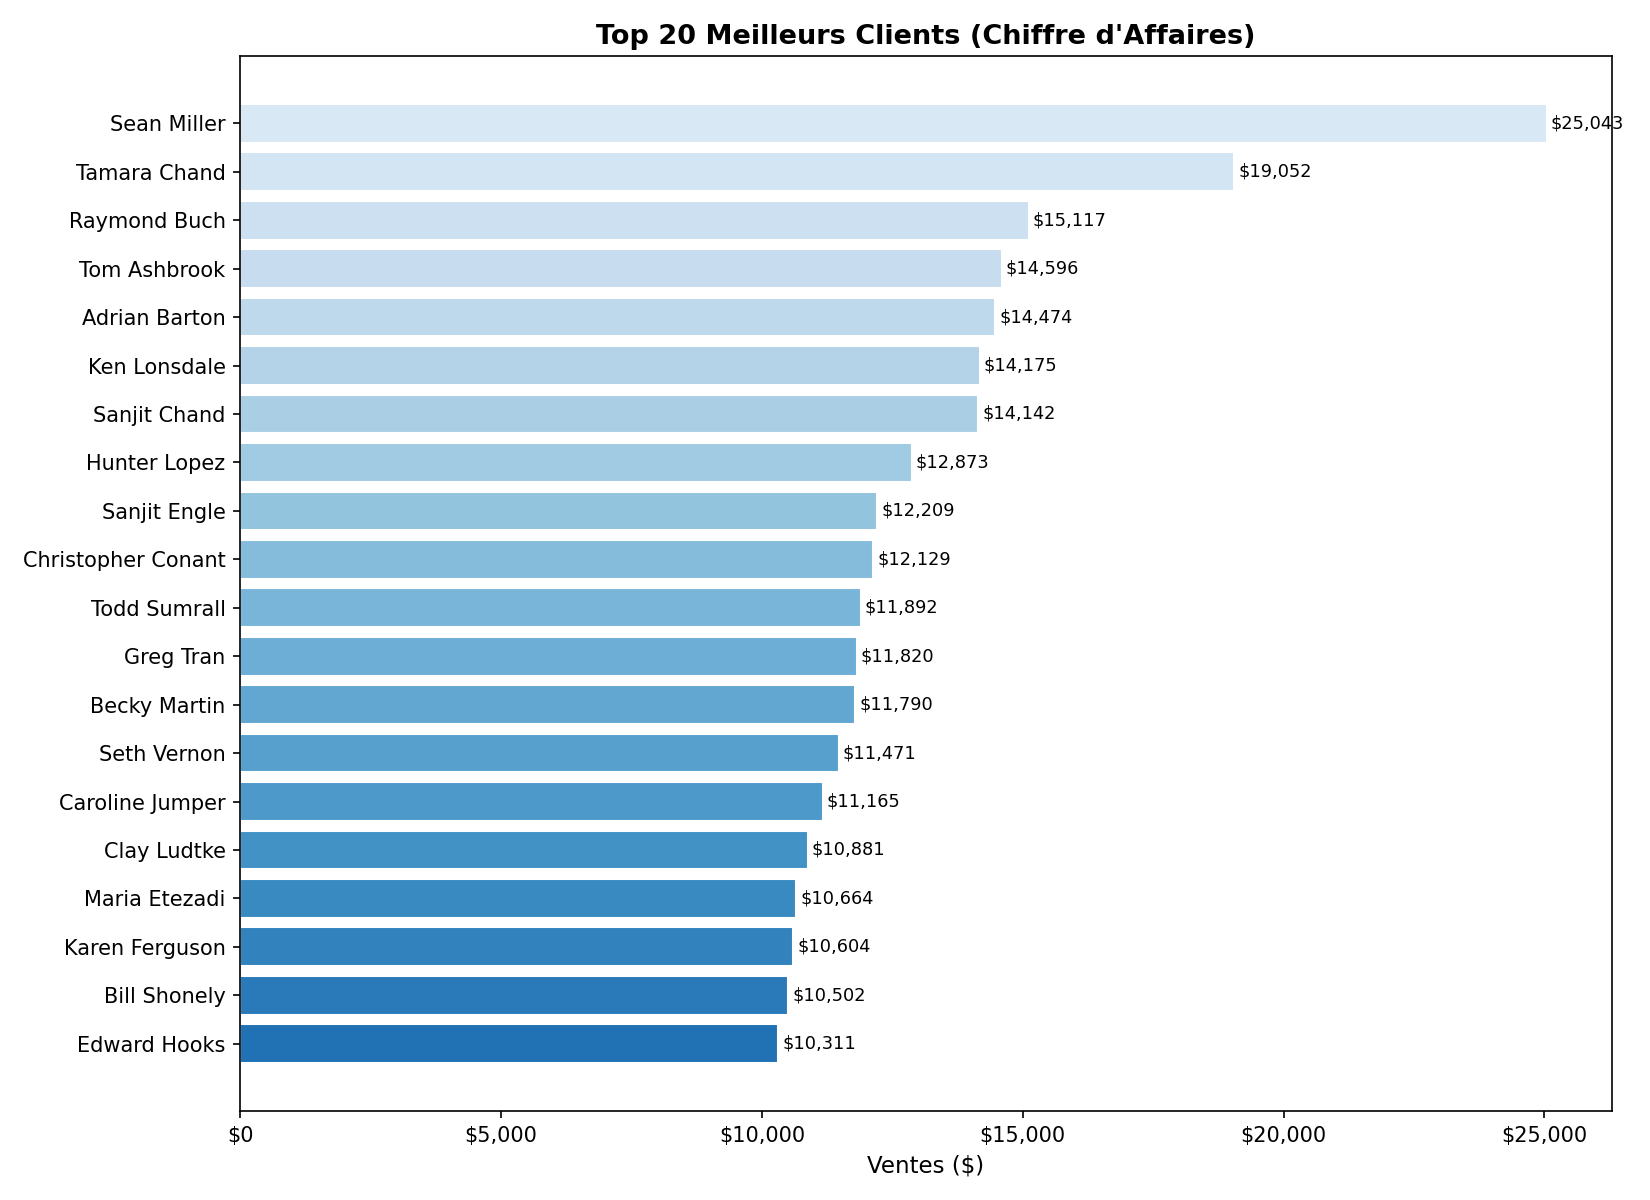

In [ ]:
# Graphique : Top 20 Clients

**Observation :** **Sean Miller** est le client avec le plus grand CA total (~$25K).
Ces 20 clients représentent une source importante de revenus à entretenir.


---
## Question 8 – Courbe Cumulative des Ventes + Pareto

On trace la courbe de Lorenz des ventes pour vérifier la règle 80/20.


In [ ]:
# Ventes cumulées par client
cust_sales = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False)
cumul_sales = cust_sales.cumsum() / cust_sales.sum() * 100
x_pct       = np.arange(1, len(cumul_sales)+1) / len(cumul_sales) * 100

idx80   = np.searchsorted(cumul_sales.values, 80)
x_at_80 = x_pct[idx80]
print(f'→ {x_at_80:.1f}% des clients génèrent 80% des ventes')
print(f'  Pareto strict : {"CONFIRMÉ " if x_at_80 <= 25 else "NON STRICT – mais concentration réelle"}')


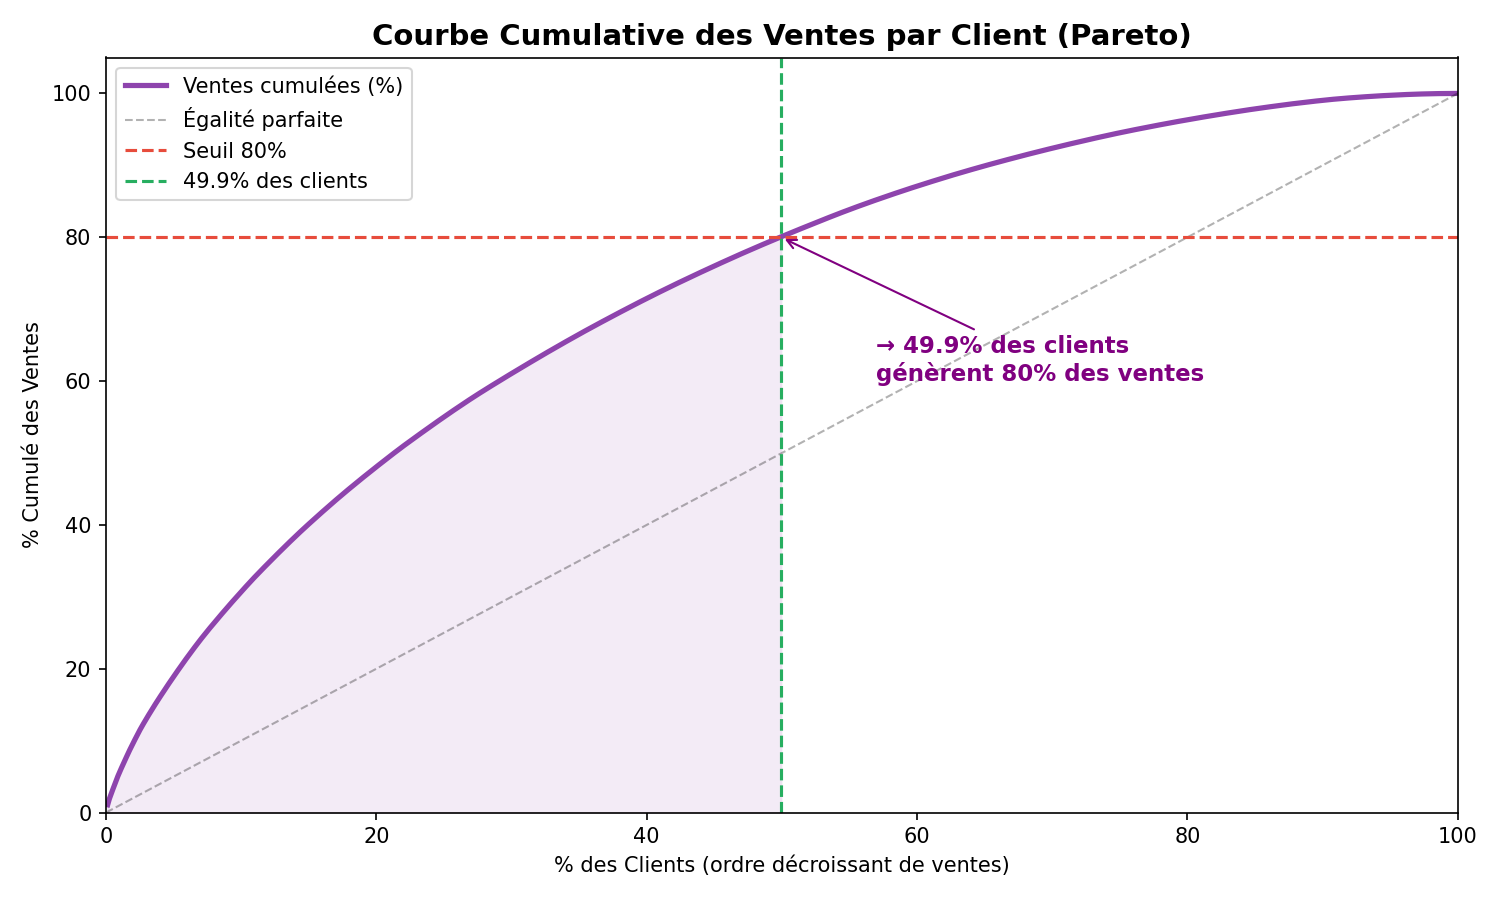

In [ ]:
# Graphique : Courbe cumulative Ventes

**Observation :** ~**50% des clients** génèrent 80% des ventes.
La règle 20/80 stricte ne tient pas, mais la concentration est bien réelle :
la moitié des clients suffit à expliquer l'essentiel des ventes.


---
## Bonus – Séries Chronologiques (Ventes & Bénéfices)


In [ ]:
# Créer une colonne Année-Mois
df['YM'] = df['Order Date'].dt.to_period('M')

# Agréger par mois
ts = df.groupby('YM')[['Sales','Profit']].sum()
ts.index = ts.index.to_timestamp()

print('Aperçu des 5 premiers mois :')
print(ts.head().round(2))


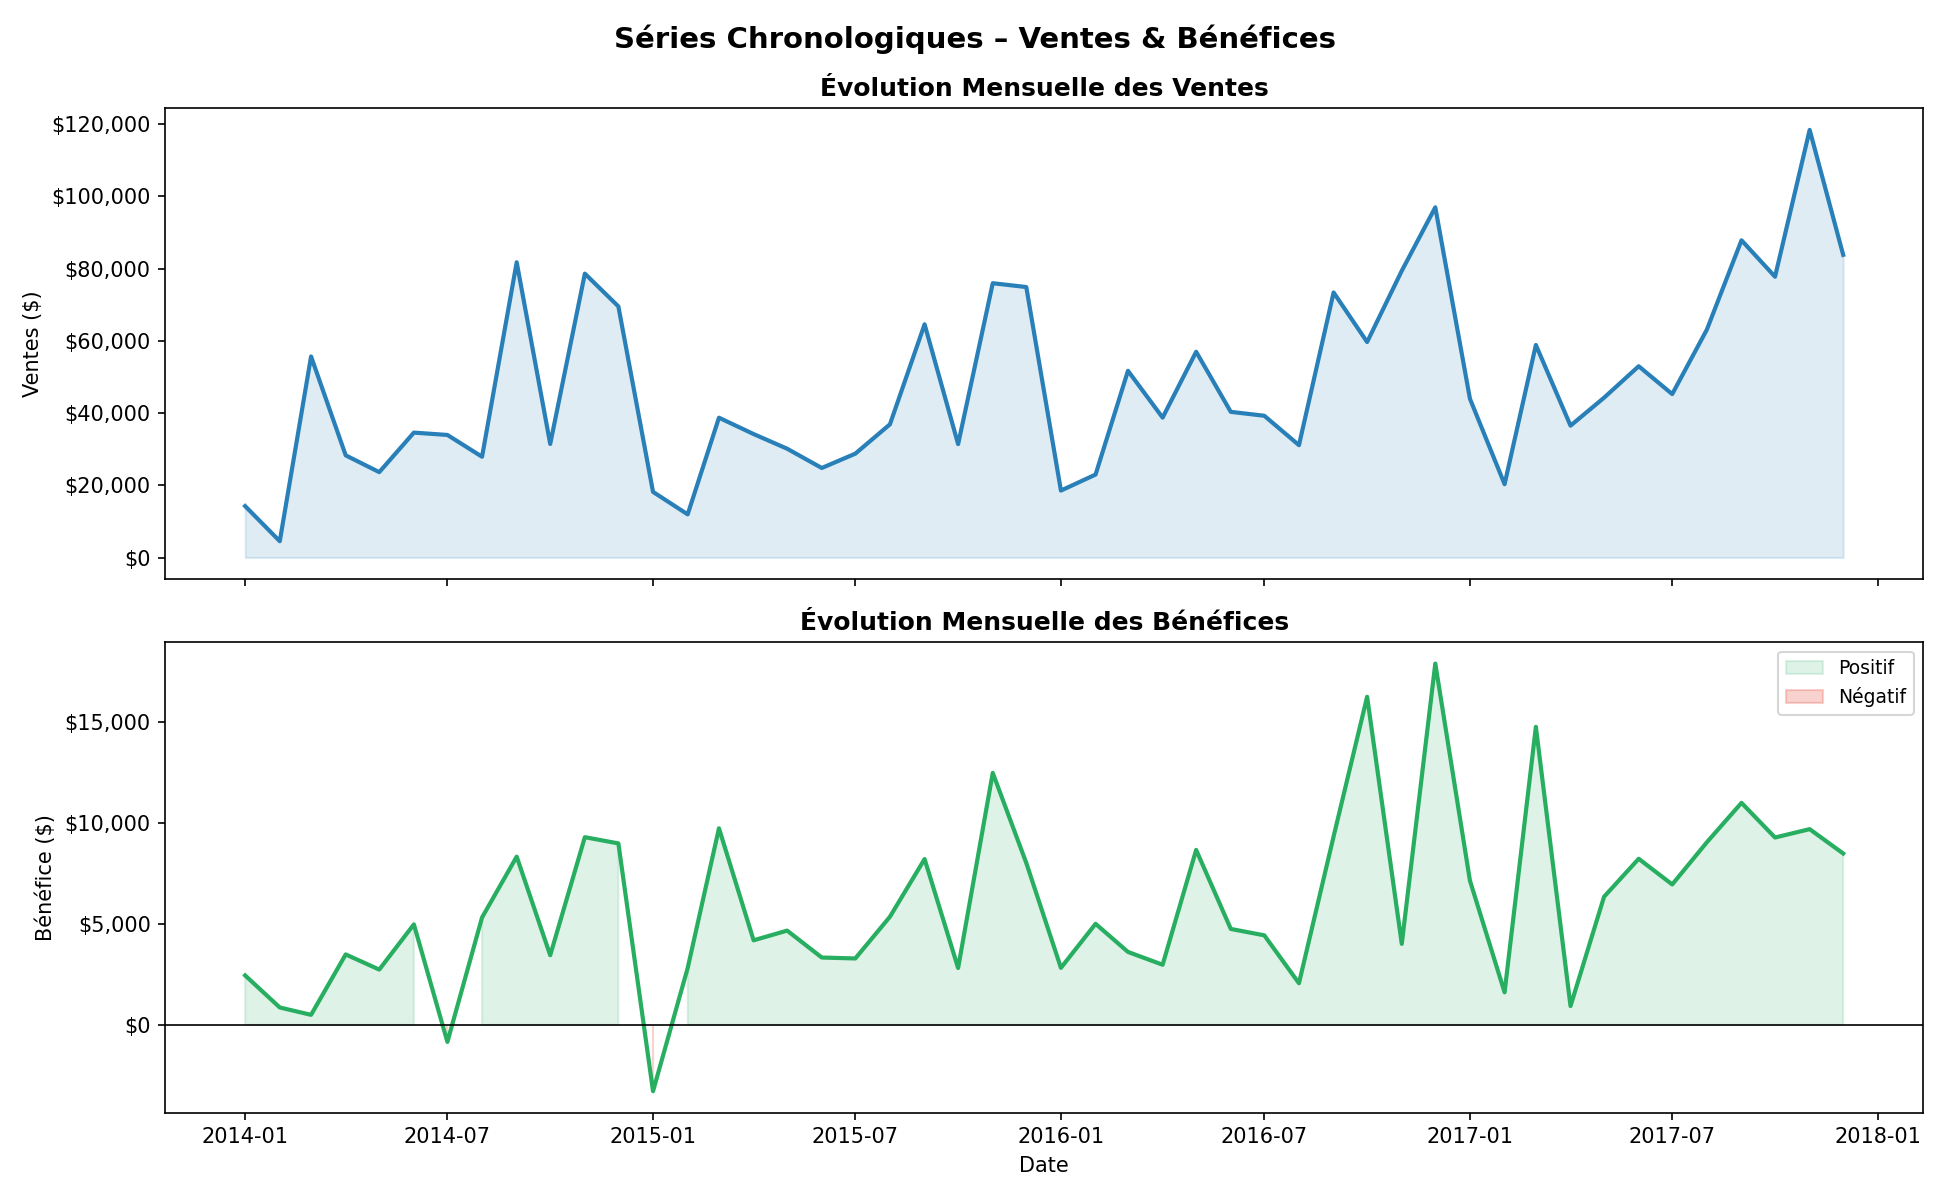

In [ ]:
+# Graphique : Séries chronologiques

**Observation :** On observe une **saisonnalité marquée** :
les ventes et bénéfices ont tendance à culminer en **fin d'année** (T4).
Certains mois affichent des bénéfices négatifs — à investiguer (remises excessives ?).


---
## Bonus – Performance par Catégorie de Produit


In [ ]:
cat = df.groupby(['Category','Sub-Category'])[['Sales','Profit']].sum().reset_index()
cat['Marge (%)'] = (cat['Profit']/cat['Sales']*100).round(2)
print(cat.sort_values('Marge (%)', ascending=False).to_string(index=False))


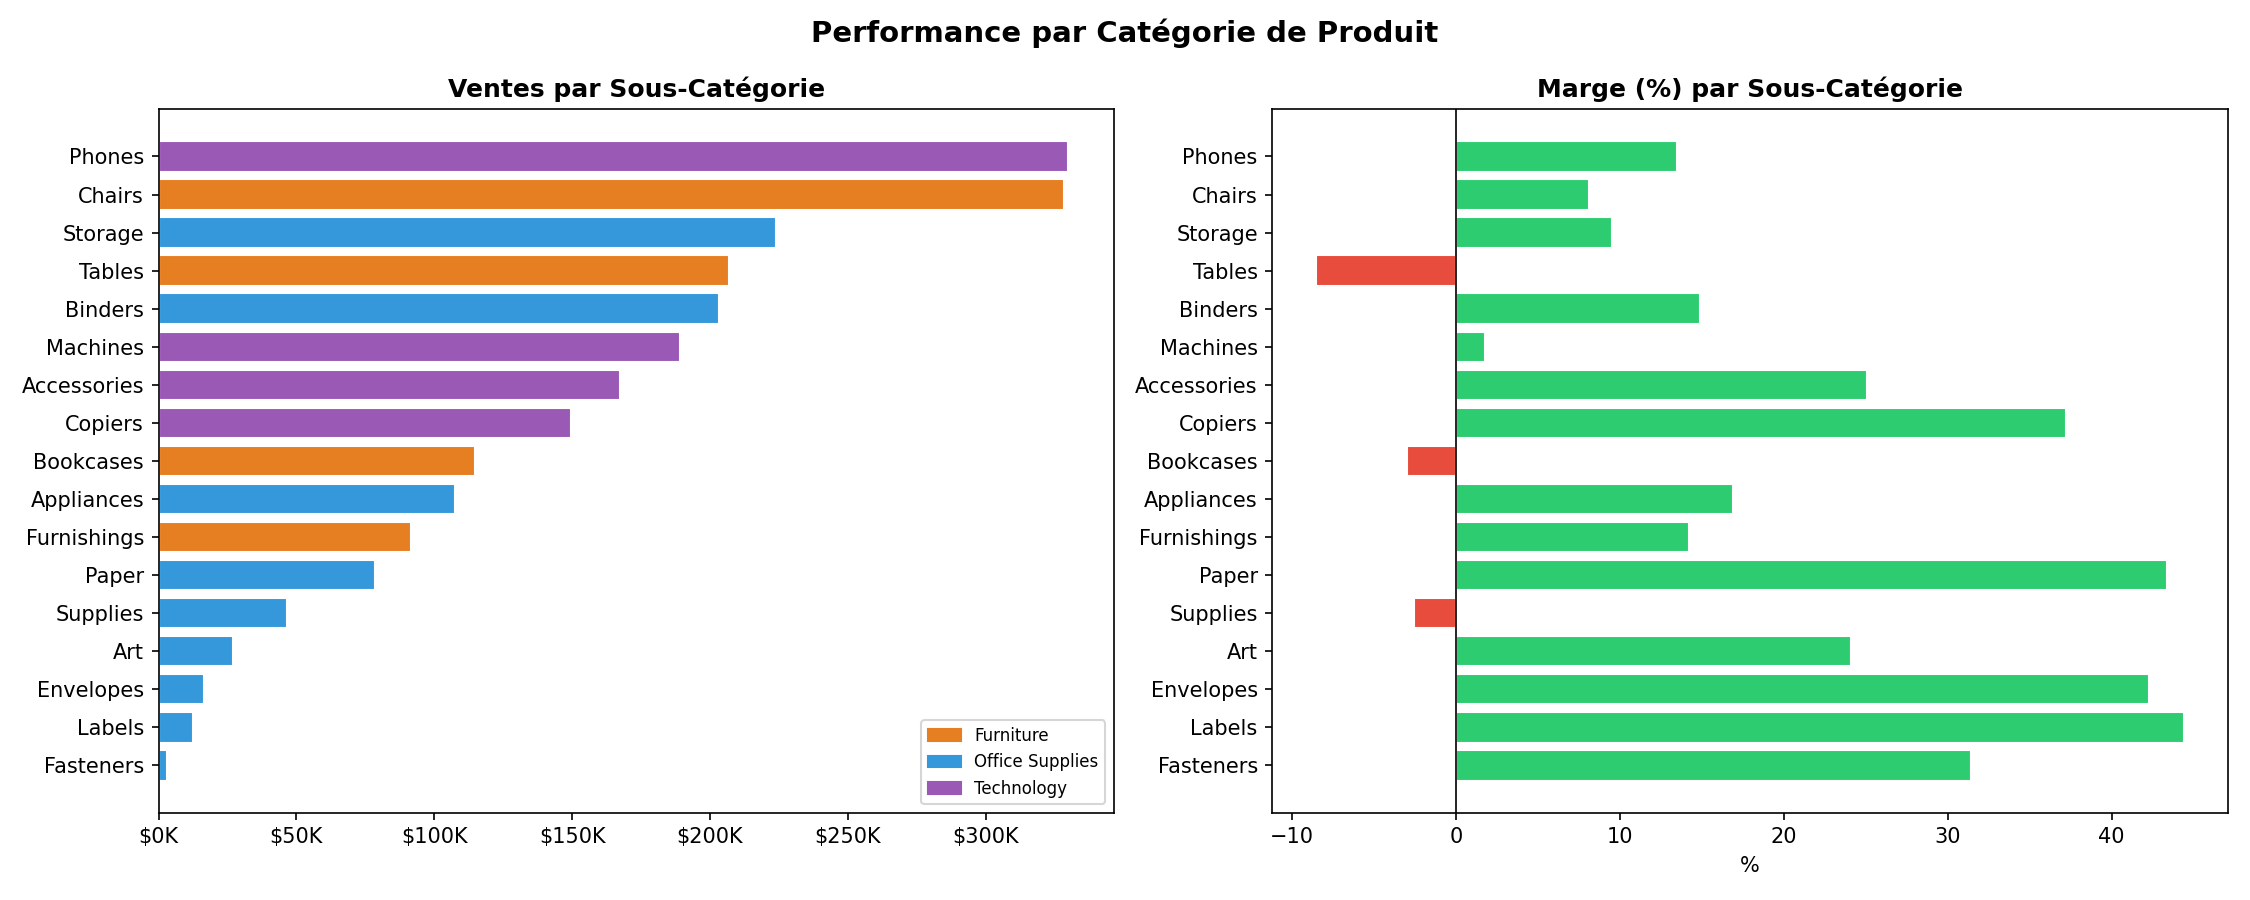

In [ ]:
# Graphique : Catégories produits

**Observation :** Les **fournitures de bureau** (Labels, Paper, Envelopes) ont les meilleures marges.
Les **Tables** sont fortement déficitaires — les remises accordées détruisent la marge.


---
## Recommandations Stratégiques

Sur la base de l'analyse complète :

### États à prioriser
-  **Californie, New York, Washington** : fort CA ET bonne rentabilité
-  **Texas** : fort CA mais marge négative → optimiser les remises
-  **Ohio, Colorado, Tennessee** : marges très négatives → revoir la politique tarifaire

### Villes à prioriser
-  **New York City, Los Angeles, Seattle, San Francisco** : forte valeur en CA et bénéfice
-  **Philadelphia** : fort CA mais pertes → à surveiller

### Clients
-  Top clients NY : **Tom Ashbrook** – programme de fidélité dédié
-  Environ **40-50%** des clients génèrent 80% des revenus → concentrer les efforts marketing sur eux

### Produits
-  Promouvoir : **Technology** (bonne marge) + **Office Supplies** (Labels, Paper)
-  Réviser : **Furniture – Tables** (marge très négative, remises à réduire)
